In [4]:
import numpy as np #Using numpy for the main routine.
import pandas as pd #Using pandas just for reading and analysis.
import h5py
import scipy
from scipy.io import loadmat
from scipy.linalg import logm
from scipy.optimize import minimize
from scipy.io.matlab import mat_struct
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import re
import numpy as np
import datetime as dt
import scipy.io
import scipy.io as sio
from collections import Counter
from scipy.interpolate import PchipInterpolator

In [6]:
cel_drivers_df = pd.read_csv('./SW-All.csv')
cel_drivers_df['datetime'] = pd.to_datetime(cel_drivers_df['DATE'])
cel_drivers_df = cel_drivers_df.set_index('datetime')
cel_drivers_df

,DATE,BSRN,ND,KP1,KP2,KP3,KP4,KP5,KP6,KP7,...,CP,C9,ISN,F10.7_OBS,F10.7_ADJ,F10.7_DATA_TYPE,F10.7_OBS_CENTER81,F10.7_OBS_LAST81,F10.7_ADJ_CENTER81,F10.7_ADJ_LAST81
datetime,,,,,,,,,,,,,,,,,,,,,
1957-10-01,1957-10-01,1700,19,43.0,40.0,30.0,20.0,37.0,23.0,43.0,...,1.1,5.0,334,269.3,269.8,OBS,266.6,230.9,266.8,235.5
1957-10-02,1957-10-02,1700,20,37.0,37.0,17.0,17.0,27.0,23.0,17.0,...,0.7,3.0,331,253.3,253.6,OBS,267.4,231.7,267.5,236.2
1957-10-03,1957-10-03,1700,21,27.0,20.0,13.0,33.0,37.0,47.0,43.0,...,1.0,5.0,343,266.3,266.4,OBS,268.1,232.7,268.1,237.1
1957-10-04,1957-10-04,1700,22,30.0,30.0,23.0,27.0,23.0,27.0,30.0,...,0.7,3.0,307,238.2,238.2,OBS,268.8,233.3,268.7,237.7
1957-10-05,1957-10-05,1700,23,30.0,30.0,17.0,23.0,20.0,27.0,27.0,...,0.6,3.0,310,246.2,246.0,OBS,269.3,233.9,269.1,238.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2041-06-01,2041-06-01,2832,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13,69.2,71.1,PRM,69.5,71.1,71.3,71.7
2041-07-01,2041-07-01,2833,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12,68.5,70.8,PRM,68.8,69.8,71.0,71.4
2041-08-01,2041-08-01,2834,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11,68.4,70.5,PRM,68.7,69.0,70.6,71.1


In [7]:
cel_drivers_df.loc[(cel_drivers_df.DATE>='2003-10-28') & (cel_drivers_df.DATE<='2003-11-07')]

,DATE,BSRN,ND,KP1,KP2,KP3,KP4,KP5,KP6,KP7,...,CP,C9,ISN,F10.7_OBS,F10.7_ADJ,F10.7_DATA_TYPE,F10.7_OBS_CENTER81,F10.7_OBS_LAST81,F10.7_ADJ_CENTER81,F10.7_ADJ_LAST81
datetime,,,,,,,,,,,,,,,,,,,,,
2003-10-28,2003-10-28,2323,26,30.0,47.0,37.0,47.0,27.0,40.0,33.0,...,1.2,6.0,247,274.4,270.9,OBS,147.0,125.6,145.1,126.5
2003-10-29,2003-10-29,2323,27,47.0,40.0,90.0,80.0,77.0,77.0,87.0,...,2.1,9.0,250,291.7,287.7,OBS,146.8,127.6,144.8,128.4
2003-10-30,2003-10-30,2324,1,87.0,73.0,53.0,47.0,50.0,70.0,90.0,...,2.1,9.0,250,271.4,267.6,OBS,146.5,129.3,144.6,130.0
2003-10-31,2003-10-31,2324,2,83.0,77.0,73.0,67.0,73.0,47.0,40.0,...,1.9,8.0,239,248.9,245.2,OBS,146.2,130.8,144.2,131.4
2003-11-01,2003-11-01,2324,3,50.0,47.0,40.0,27.0,30.0,33.0,33.0,...,1.2,6.0,153,210.4,207.2,OBS,145.8,131.8,143.8,132.4
2003-11-02,2003-11-02,2324,4,33.0,37.0,33.0,30.0,27.0,33.0,43.0,...,1.0,5.0,138,190.4,187.4,OBS,145.4,132.6,143.3,133.1
2003-11-03,2003-11-03,2324,5,33.0,30.0,27.0,27.0,20.0,23.0,27.0,...,0.7,3.0,89,166.9,164.2,OBS,144.9,133.0,142.8,133.4
2003-11-04,2003-11-04,2324,6,30.0,30.0,63.0,70.0,27.0,20.0,33.0,...,1.4,6.0,64,560.9,551.6,OBS,144.4,138.3,142.2,138.6
2003-11-05,2003-11-05,2324,7,17.0,0.0,13.0,10.0,7.0,13.0,23.0,...,0.3,1.0,15,114.0,112.1,OBS,144.0,138.2,141.8,138.4


Uses monotonic cubic splines to interpolate $F_{10}$.

In [8]:
cel_drivers_df.columns

Index(['DATE', 'BSRN', 'ND', 'KP1', 'KP2', 'KP3', 'KP4', 'KP5', 'KP6', 'KP7',
       'KP8', 'KP_SUM', 'AP1', 'AP2', 'AP3', 'AP4', 'AP5', 'AP6', 'AP7', 'AP8',
       'AP_AVG', 'CP', 'C9', 'ISN', 'F10.7_OBS', 'F10.7_ADJ',
       'F10.7_DATA_TYPE', 'F10.7_OBS_CENTER81', 'F10.7_OBS_LAST81',
       'F10.7_ADJ_CENTER81', 'F10.7_ADJ_LAST81'],
      dtype='object')

In [9]:
cel_drivers_f107_df_long = cel_drivers_df[['F10.7_OBS_LAST81']]
cel_drivers_f107_df_long = cel_drivers_f107_df_long.stack().reset_index().rename(columns = {'level_1': 'f107_time', 0: 'f107'})
cel_drivers_f107_df_long

,datetime,f107_time,f107
0,1957-10-01,F10.7_OBS_LAST81,230.9
1,1957-10-02,F10.7_OBS_LAST81,231.7
2,1957-10-03,F10.7_OBS_LAST81,232.7
3,1957-10-04,F10.7_OBS_LAST81,233.3
4,1957-10-05,F10.7_OBS_LAST81,233.9
...,...,...,...
25170,2041-06-01,F10.7_OBS_LAST81,71.1
25171,2041-07-01,F10.7_OBS_LAST81,69.8
25172,2041-08-01,F10.7_OBS_LAST81,69.0
25173,2041-09-01,F10.7_OBS_LAST81,68.7


In [10]:
counter = 0
df_lst = []
for label in ['F10.7_OBS', 'F10.7_ADJ']:
    if label == 'F10.7_OBS':
        adj_label = 'f107_obs'
    elif label == 'F10.7_ADJ':
        adj_label = 'f107_adj'
    elif label == 'F10.7_OBS_LAST81':
        adj_label = 'f107_obs_ma'
    elif label == 'F10.7_ADJ_LAST81':
        adj_label = 'f107_adj_ma'

    cel_drivers_f107_df_long = cel_drivers_df[[label]]
    cel_drivers_f107_df_long = cel_drivers_f107_df_long.stack().reset_index().rename(columns = {'level_1': 'f107_time', 0: 'f107'})

    # df has: datetime (daily at 00:00), f107
    df = cel_drivers_f107_df_long.copy()
    df["f107"] = pd.to_numeric(df["f107"], errors="coerce")
    mask = df["f107"] > 300
    df.loc[mask, "f107"] = np.nan
    df["f107"] = df["f107"].ffill()
    df["f107"] = df["f107"].bfill()

    # ensure sorted + unique daily timestamps
    df = df.sort_values("datetime").drop_duplicates("datetime")

    t0 = df["datetime"].iloc[0]

    # x = days (or hours) since start; choose hours to match hourly query directly
    x = (df["datetime"] - t0).dt.total_seconds().to_numpy() / 3600.0   # daily points spaced by 24 hours
    y = df["f107"].to_numpy()

    # hourly grid across the full span
    t_hourly = pd.date_range(df["datetime"].min(),
                            df["datetime"].max() + pd.Timedelta(hours=23),
                            freq="h")
    xq = (t_hourly - t0).total_seconds().to_numpy() / 3600.0

    # PCHIP interpolate
    f = PchipInterpolator(x, y, extrapolate=False)
    yq = f(xq)

    f107_hourly_pchip = pd.DataFrame({"datetime": t_hourly, adj_label: yq})
    if counter > 0:
        f107_hourly_pchip.drop(columns=['datetime'], inplace=True)

    # if you want to drop NaNs at the edges (because extrapolate=False)
    f107_hourly_pchip = f107_hourly_pchip.dropna().reset_index(drop=True)
    df_lst.append(f107_hourly_pchip)
    counter = counter + 1

cel_f107_df = pd.concat(df_lst, axis=1)
# cel_f107_df.to_csv('./drivers/f107_celestrak_with_cap.csv', index=False)
cel_f107_df

,datetime,f107_obs,f107_adj
0,1957-10-01 00:00:00,269.300000,269.800000
1,1957-10-01 01:00:00,268.051845,268.543179
2,1957-10-01 02:00:00,266.849479,267.331539
3,1957-10-01 03:00:00,265.693555,266.165820
4,1957-10-01 04:00:00,264.584722,265.046759
...,...,...,...
736340,2041-09-30 20:00:00,69.793867,70.000866
736341,2041-09-30 21:00:00,69.795400,70.000649
736342,2041-09-30 22:00:00,69.796933,70.000433
736343,2041-09-30 23:00:00,69.798466,70.000216


1963-04-16 00:00:00


<Axes: xlabel='datetime'>

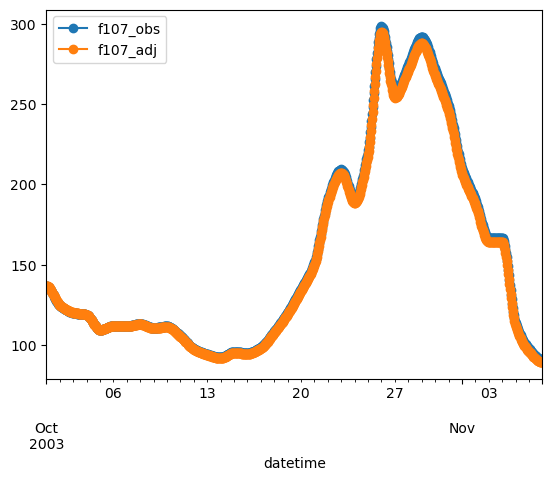

In [11]:
day0 = cel_f107_df["datetime"].dt.normalize().iloc[np.random.randint(0, cel_f107_df.shape[0])]
tmp = cel_f107_df.loc[(cel_f107_df.datetime>='2003-10-01') & (cel_f107_df.datetime<='2003-11-07')]
# tmp = f107_hourly_pchip[f107_hourly_pchip["datetime"].dt.normalize() == day0]
print(day0)
tmp.plot(x="datetime", y=["f107_obs", "f107_adj"], marker="o")

Uses monotonic cubic splines to interpolate $k_p$.

In [12]:
cel_drivers_kp_df_long = cel_drivers_df.filter(like='KP').iloc[:, :-1]
cel_drivers_kp_df_long = cel_drivers_kp_df_long.stack().reset_index().rename(columns = {'level_1': 'kp_time', 0: 'kp'})
cel_drivers_kp_df_long

,datetime,kp_time,kp
0,1957-10-01,KP1,43.0
1,1957-10-01,KP2,40.0
2,1957-10-01,KP3,30.0
3,1957-10-01,KP4,20.0
4,1957-10-01,KP5,37.0
...,...,...,...
199899,2026-02-28,KP4,13.0
199900,2026-02-28,KP5,13.0
199901,2026-02-28,KP6,13.0
199902,2026-02-28,KP7,13.0


In [ ]:

# df has columns: datetime (timestamp for the day), kp_time like "KP1..KP8" or similar, kp
# you already computed:
# df["kp_idx"] = df["kp_time"].str.extract(r"KP(\d+)").astype(int) - 1
# df["t3h"]    = df["datetime"] + pd.to_timedelta(df["kp_idx"] * 3, unit="h")

df = cel_drivers_kp_df_long.copy()
df["kp_idx"] = df["kp_time"].str.extract(r"KP(\d+)").astype(int) - 1
df["t3h"]    = df["datetime"] + pd.to_timedelta(df["kp_idx"] * 3, unit="h")
# make sure kp is REAL numeric
df["kp"] = pd.to_numeric(df["kp"], errors="coerce")

# day key
df["day"] = pd.to_datetime(df["datetime"]).dt.floor("D")

# next day 0h kp (i.e., the first kp value of the next day)
next_day_kp0 = (
    df.sort_values(["day", "t3h"])
      .groupby("day")["kp"].first()
      .shift(-1)
)

out = []
days = next_day_kp0.index

for day in days[:-1]:  # last day has no "next day" to anchor to
    g = df[df["day"] == day].sort_values("t3h")

    # need the 3-hourly knots for the day
    x = ((g["t3h"] - day).dt.total_seconds().to_numpy()) / 3600.0  # [0,3,...,21]
    y = g["kp"].to_numpy(dtype=float)

    # skip if bad data
    if len(x) < 2 or np.any(~np.isfinite(y)):
        continue

    # append the anchor knot at hour 24 using next day's first kp
    y24 = float(next_day_kp0.loc[day])
    x = np.r_[x, 24.0]
    y = np.r_[y, y24]

    # enforce increasing x (required)
    order = np.argsort(x)
    x, y = x[order], y[order]

    f = PchipInterpolator(x, y, extrapolate=False)

    xq = np.arange(24.0)  # 0..23
    yq = f(xq)

    out.append(pd.DataFrame({
        "datetime": day + pd.to_timedelta(xq, unit="h"),
        "kp": yq
    }))

kp_hourly_smooth = pd.concat(out, ignore_index=True)
kp_hourly_smooth.kp = kp_hourly_smooth.kp/10.
# kp_hourly_smooth.to_csv('./drivers/kp_celestrak.csv', index = False)
kp_hourly_smooth


,datetime,kp
0,1957-10-01 00:00:00,43.000000
1,1957-10-01 01:00:00,42.564103
2,1957-10-01 02:00:00,41.461538
3,1957-10-01 03:00:00,40.000000
4,1957-10-01 04:00:00,37.464387
...,...,...
599683,2026-02-27 19:00:00,24.000000
599684,2026-02-27 20:00:00,24.000000
599685,2026-02-27 21:00:00,24.000000
599686,2026-02-27 22:00:00,22.370370


1982-10-11 00:00:00


<Axes: xlabel='datetime'>

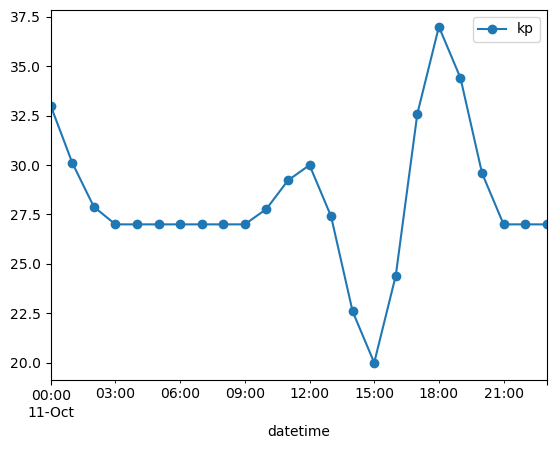

In [14]:
day0 = kp_hourly_smooth["datetime"].dt.normalize().iloc[np.random.randint(0, kp_hourly_smooth.shape[0])]
tmp = kp_hourly_smooth[kp_hourly_smooth["datetime"].dt.normalize() == day0]
print(day0)
tmp.plot(x="datetime", y="kp", marker="o")


Preprocessing drivers for training

In [15]:
celestrak_drivers_df = pd.merge(cel_f107_df, kp_hourly_smooth, on='datetime', how = 'inner')
# celestrak_drivers_df.to_csv('./drivers/celestrak_drivers_no_preprocess_with_cap.csv', index=False)

doy_c = np.cos(2*np.pi*(celestrak_drivers_df.datetime.dt.day_of_year.values + celestrak_drivers_df.datetime.dt.hour.values/24.)/365.25)
doy_s = np.sin(2*np.pi*(celestrak_drivers_df.datetime.dt.day_of_year.values + celestrak_drivers_df.datetime.dt.hour.values/24.)/365.25)
ut_c = np.cos(2*np.pi*(celestrak_drivers_df.datetime.dt.hour.values)/24.)
ut_s = np.sin(2*np.pi*(celestrak_drivers_df.datetime.dt.hour.values)/24.)

celestrak_drivers_df['year'] = celestrak_drivers_df.datetime.dt.year
celestrak_drivers_df['doy'] = celestrak_drivers_df.datetime.dt.day_of_year
celestrak_drivers_df['hour'] = celestrak_drivers_df.datetime.dt.hour
celestrak_drivers_df['t1'] = doy_c
celestrak_drivers_df['t2'] = doy_s
celestrak_drivers_df['t3'] = ut_c
celestrak_drivers_df['t4'] = ut_s
celestrak_drivers_df = celestrak_drivers_df[['year', 't1', 't2', 't3', 't4', 'f107_adj', 'kp', 'datetime', 'doy', 'hour', 'f107_obs']]
celestrak_drivers_df.rename(columns={'f107_adj': 'f107'}, inplace=True)
# celestrak_drivers_df.to_csv('./drivers/celestrak_drivers_preprocessed.csv', index=False)
celestrak_drivers_df

,year,t1,t2,t3,t4,f107,kp,datetime,doy,hour,f107_obs
0,1957,0.001075,-0.999999,1.000000,0.000000,269.800000,43.000000,1957-10-01 00:00:00,274,0,269.300000
1,1957,0.001792,-0.999998,0.965926,0.258819,268.543179,42.564103,1957-10-01 01:00:00,274,1,268.051845
2,1957,0.002509,-0.999997,0.866025,0.500000,267.331539,41.461538,1957-10-01 02:00:00,274,2,266.849479
3,1957,0.003225,-0.999995,0.707107,0.707107,266.165820,40.000000,1957-10-01 03:00:00,274,3,265.693555
4,1957,0.003942,-0.999992,0.500000,0.866025,265.046759,37.464387,1957-10-01 04:00:00,274,4,264.584722
...,...,...,...,...,...,...,...,...,...,...,...
599683,2026,0.530709,0.847554,0.258819,-0.965926,125.560619,24.000000,2026-02-27 19:00:00,58,19,127.983044
599684,2026,0.530102,0.847934,0.500000,-0.866025,125.370370,24.000000,2026-02-27 20:00:00,58,20,127.785185
599685,2026,0.529494,0.848314,0.707107,-0.707107,125.214844,24.000000,2026-02-27 21:00:00,58,21,127.623438
599686,2026,0.528886,0.848693,0.866025,-0.500000,125.098380,22.370370,2026-02-27 22:00:00,58,22,127.502315
